In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use('default')
log_dir = Path('../logs')
if not log_dir.exists():
    print("No logs dir found.")

In [ ]:
def load_logs(file_path):
    with open(file_path, 'r') as f:
        data = json.load(f)
    return pd.DataFrame(data)

data_frames = {}
if log_dir.exists():
    for p in log_dir.glob('*.json'):
        data_frames[p.stem] = load_logs(p)
        print(f"Loaded {p.stem}: {len(data_frames[p.stem])} episodes")

Loaded h2_vqe_ddqn_seed42: 2000 episodes
Loaded h2_vqe_ppo_seed42: 2000 episodes
Loaded baseline_comparison: 12 episodes


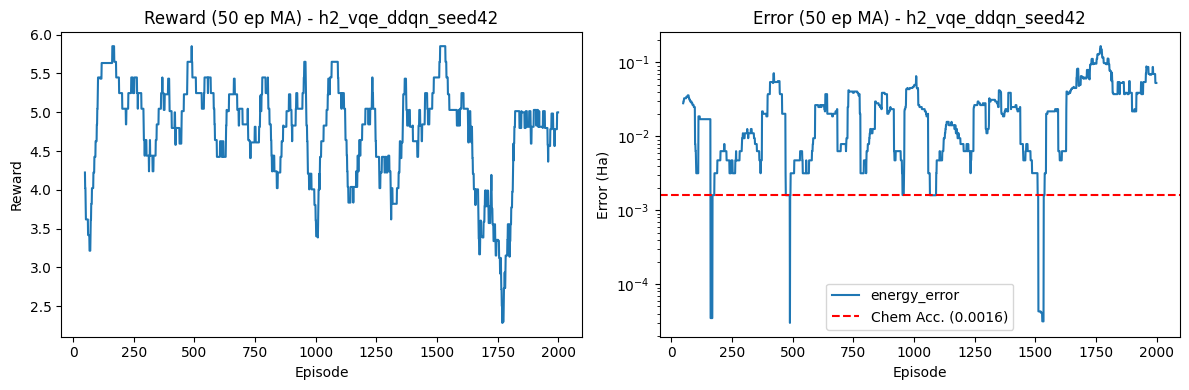

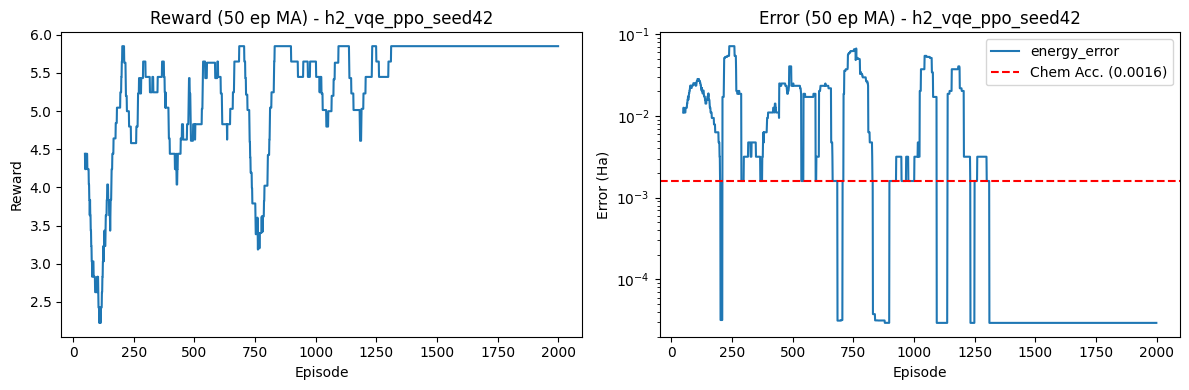

In [ ]:
for name, df in data_frames.items():
    if 'reward' not in df.columns:
        continue
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    window_size = min(50, len(df))
    df['reward'].rolling(window_size).mean().plot(ax=ax1)
    ax1.set_title(f'Reward ({window_size} ep MA) - {name}')
    ax1.set_xlabel('Episode')
    ax1.set_ylabel('Reward')
    
    df['energy_error'].rolling(window_size).mean().plot(ax=ax2)
    ax2.set_title(f'Error ({window_size} ep MA) - {name}')
    ax2.axhline(0.0016, color='r', linestyle='--', label='Chem Acc. (0.0016)')
    ax2.set_xlabel('Episode')
    ax2.set_ylabel('Error (Ha)')
    ax2.set_yscale('log')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()
